In [1]:
#basic libraries to include
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('iris/iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
#droping id column not needed for analysis or ml tasks
df = df.drop('Id', axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


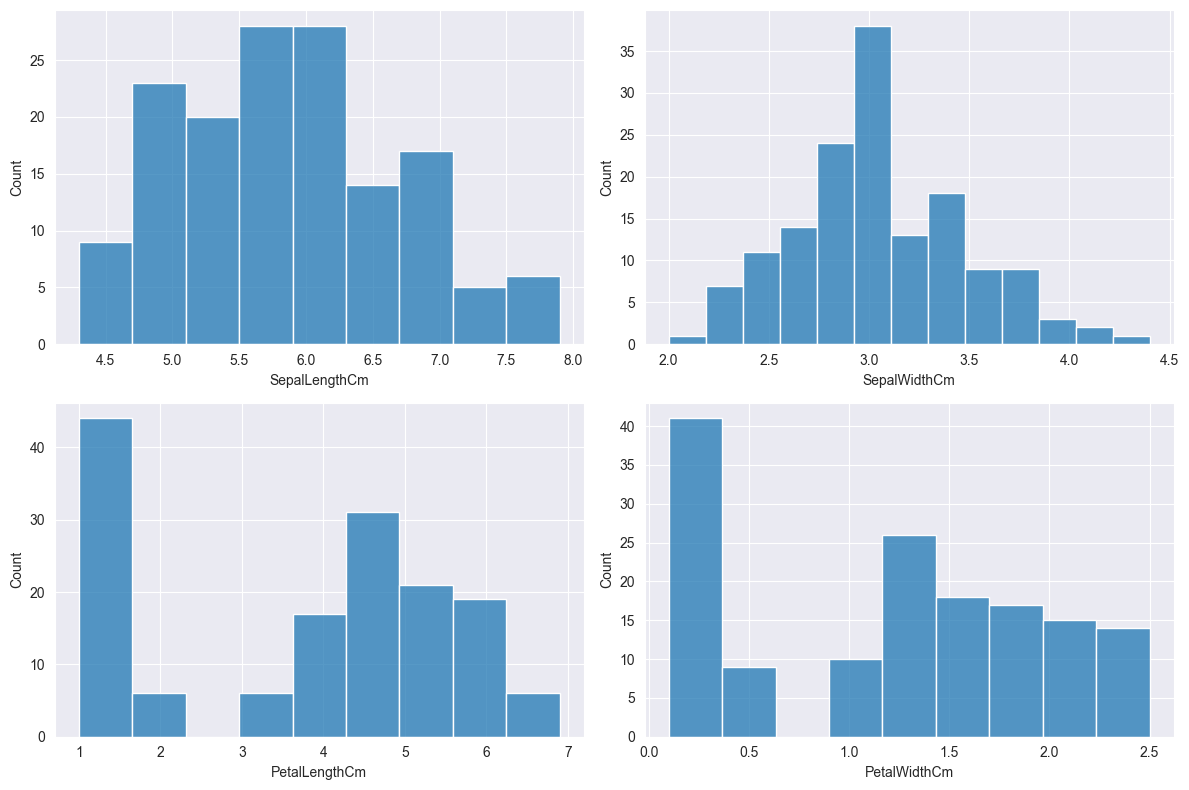

In [4]:
#ploting the distributions of the data
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data=df, x='SepalLengthCm', ax=axes[0, 0])
sns.histplot(data=df, x='SepalWidthCm', ax=axes[0, 1])
sns.histplot(data=df, x='PetalLengthCm', ax=axes[1, 0])
sns.histplot(data=df, x='PetalWidthCm', ax=axes[1, 1])
plt.tight_layout()
plt.show()

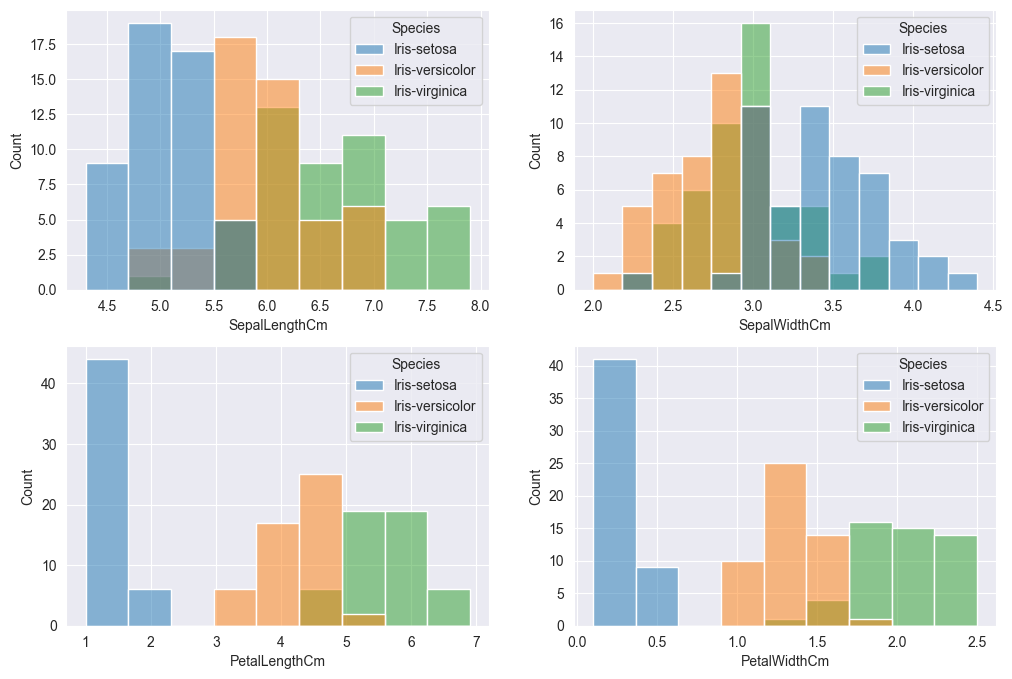

In [5]:
#same as above but colored by the Species column
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(data=df, x='SepalLengthCm', hue='Species', ax=axes[0, 0])
sns.histplot(data=df, x='SepalWidthCm', hue='Species', ax=axes[0, 1])
sns.histplot(data=df, x='PetalLengthCm', hue='Species', ax=axes[1, 0])
sns.histplot(data=df, x='PetalWidthCm', hue='Species', ax=axes[1, 1])
plt.show()

In [6]:
#check for imbalance in dataset this one is perfectly balanced
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

 # There are some noticeable correlations between all the features but petal length and pedal width are vary highly correlated

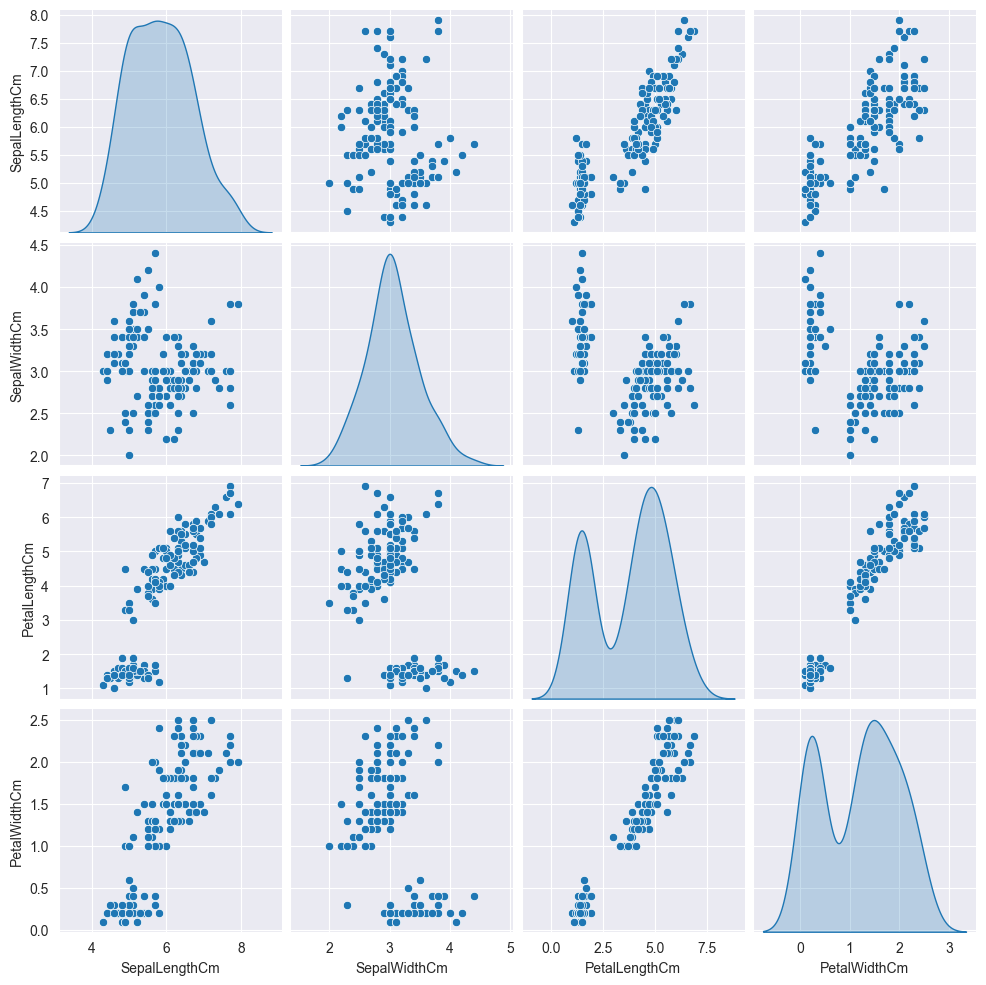

In [7]:
#checking relationships between each column
# the diagonals will make a kde (similar to histogram) because you can't compare a column to itself as a scatter plot
sns.pairplot(df, diag_kind='kde')
plt.show()

# sepal length and sepal width are the least correlated I will selected sepal length, sepal width and pedal length as my features for ml

<Axes: >

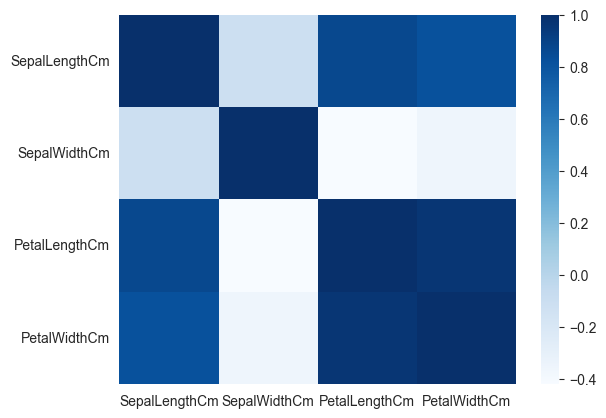

In [8]:
sns.heatmap(df.drop('Species', axis=1).corr(), cmap='Blues')

# will reapeat like before but take Species into account

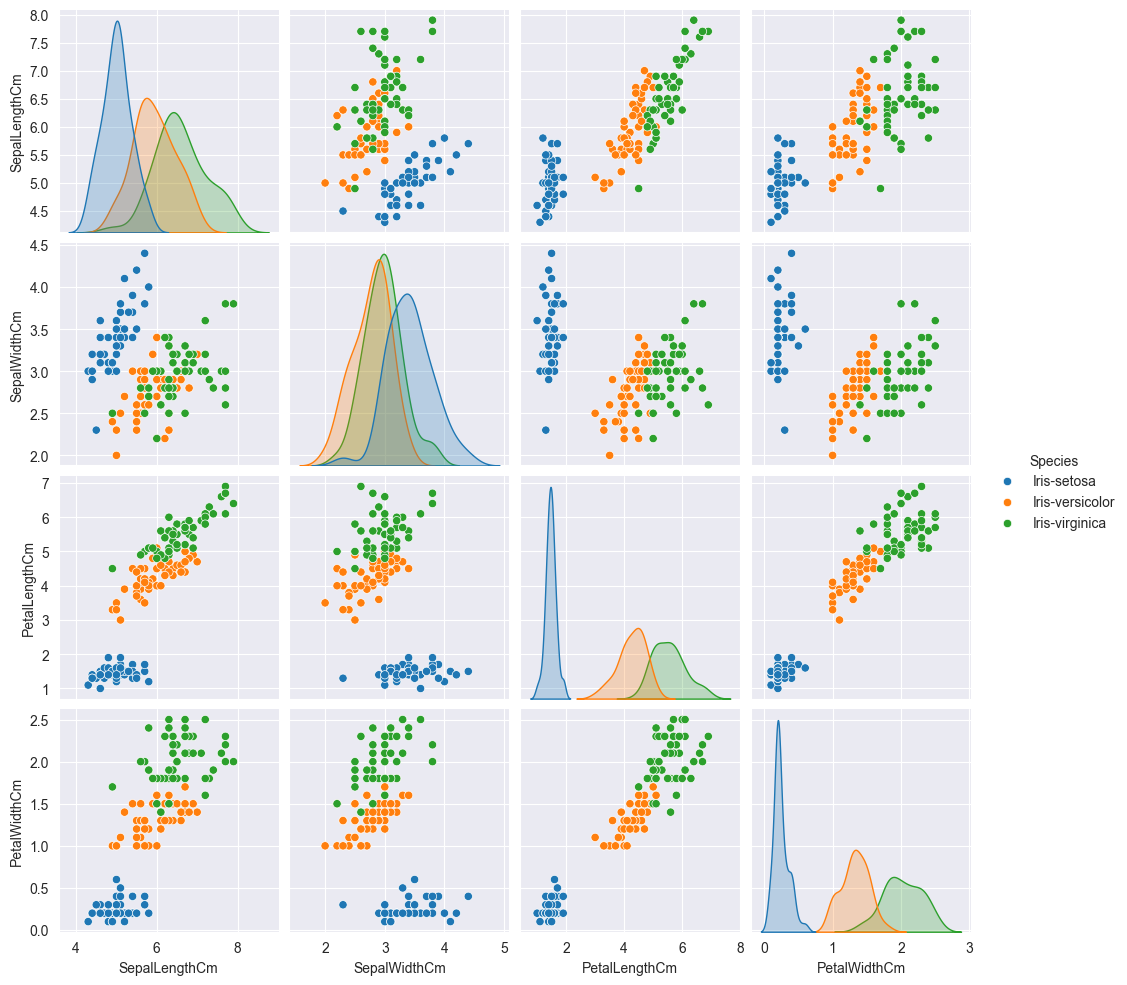

In [9]:
sns.pairplot(df, hue='Species', diag_kind='kde')
plt.show()

# All 3 features compared with the Species as the color

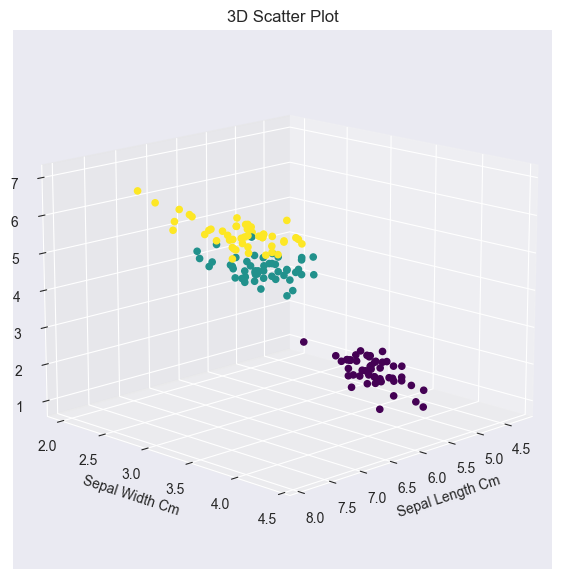

In [10]:
def scatter_plot_3d(df, label_colors):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        data=df, xs='SepalLengthCm', ys='SepalWidthCm', zs='PetalLengthCm', 
        c=label_colors, alpha=1, cmap='viridis'
    )

    # Labels and title
    ax.set_xlabel('Sepal Length Cm')
    ax.set_ylabel('Sepal Width Cm')
    ax.set_zlabel('Petal Length Cm')
    ax.set_title('3D Scatter Plot')
    ax.view_init(elev=15, azim=45)
    plt.show()
    

color_map = {'Iris-setosa': 1, 'Iris-versicolor': 2, 'Iris-virginica': 3}
colors = list(map(lambda species: color_map[species], df.Species))
scatter_plot_3d(df, colors)

In [11]:
#create the train and test set
from sklearn.model_selection import train_test_split
X = df.drop(['Species', 'PetalWidthCm'], axis=1)
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(120, 3) (30, 3) (120,) (30,)


In [12]:
X_train

,SepalLengthCm,SepalWidthCm,PetalLengthCm
22,4.6,3.6,1.0
15,5.7,4.4,1.5
65,6.7,3.1,4.4
11,4.8,3.4,1.6
42,4.4,3.2,1.3
...,...,...,...
71,6.1,2.8,4.0
106,4.9,2.5,4.5
14,5.8,4.0,1.2
92,5.8,2.6,4.0


In [13]:
y_train

22         Iris-setosa
15         Iris-setosa
65     Iris-versicolor
11         Iris-setosa
42         Iris-setosa
            ...       
71     Iris-versicolor
106     Iris-virginica
14         Iris-setosa
92     Iris-versicolor
102     Iris-virginica
Name: Species, Length: 120, dtype: object

In [14]:
X_test

,SepalLengthCm,SepalWidthCm,PetalLengthCm
73,6.1,2.8,4.7
18,5.7,3.8,1.7
118,7.7,2.6,6.9
78,6.0,2.9,4.5
76,6.8,2.8,4.8
31,5.4,3.4,1.5
64,5.6,2.9,3.6
141,6.9,3.1,5.1
68,6.2,2.2,4.5
82,5.8,2.7,3.9


In [15]:
y_test

73     Iris-versicolor
18         Iris-setosa
118     Iris-virginica
78     Iris-versicolor
76     Iris-versicolor
31         Iris-setosa
64     Iris-versicolor
141     Iris-virginica
68     Iris-versicolor
82     Iris-versicolor
110     Iris-virginica
12         Iris-setosa
36         Iris-setosa
9          Iris-setosa
19         Iris-setosa
56     Iris-versicolor
104     Iris-virginica
69     Iris-versicolor
55     Iris-versicolor
132     Iris-virginica
29         Iris-setosa
127     Iris-virginica
26         Iris-setosa
128     Iris-virginica
131     Iris-virginica
145     Iris-virginica
108     Iris-virginica
143     Iris-virginica
45         Iris-setosa
30         Iris-setosa
Name: Species, dtype: object

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



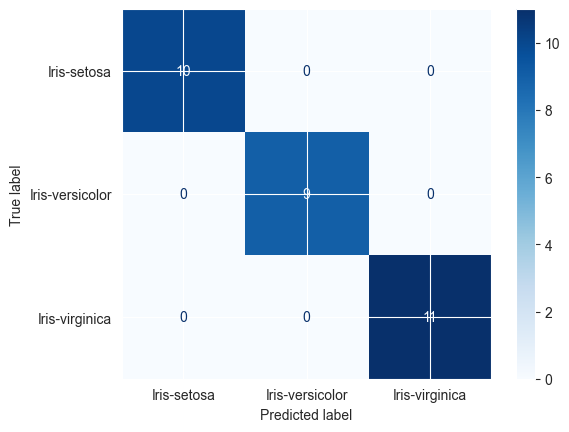

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#will create a logistic regression model
# note that this model is for classification not regression despite the name
lr = LogisticRegression()
lr.fit(X_train, y_train) # the training step
y_pred = lr.predict(X_test) # creates a prediction

# will now compare the prediction to the y_test
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=y.unique())
disp.plot(cmap='Blues')
plt.show()

# will now do a unsupervised technique on the dataset to predict the flower species

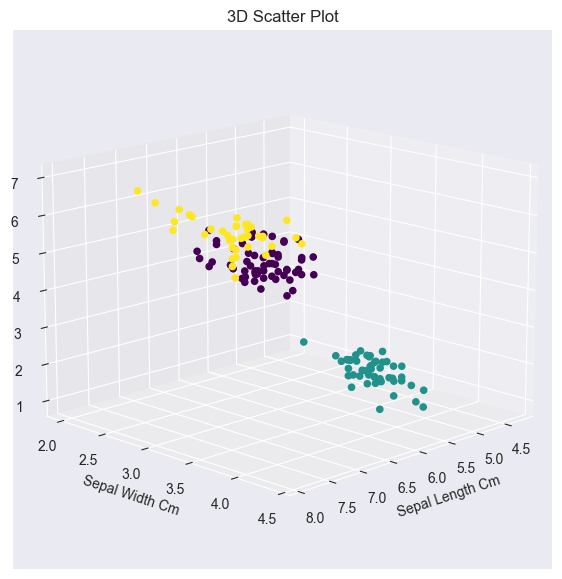

In [17]:
from sklearn.cluster import KMeans

#notice no y or train or test sets (no labels)
X = df.drop('Species', axis=1)

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
labels = kmeans.predict(X) # will get the cluster labels

scatter_plot_3d(X, labels) # note the clusters are not directly measuring the species column

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.77      0.94      0.85        50
 Iris-virginica       0.92      0.72      0.81        50

       accuracy                           0.89       150
      macro avg       0.90      0.89      0.89       150
   weighted avg       0.90      0.89      0.89       150



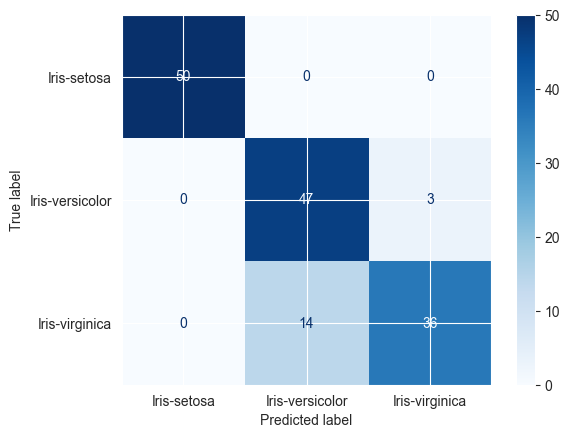

In [18]:
# a function to see if the clusters by the kmeans is correlated with the species
cluster_label_map = {}
label_df = pd.DataFrame({'true_label': y, 'predicted_label': labels})
for cluster in np.unique(labels):
    most_common_label = label_df[label_df['predicted_label'] == cluster]['true_label'].mode()[0]
    cluster_label_map[cluster] = most_common_label
mapped_labels = np.array([cluster_label_map[label] for label in labels])
print(classification_report(y, mapped_labels))
cm = confusion_matrix(y, mapped_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=y.unique())
disp.plot(cmap='Blues')
plt.show()